<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5217: Natural Language Processing</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 2: Language Modelling (Text classification) </h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Text Classification**

Text classification automatically assigns predefined categories to text based on its content (MonkeyLearn Inc., 2022). It is widely used to extract insights from large volumes of text data, making it an increasingly valuable tool in business and research.

#### **Gender Classification in Tweets by Comparing Writing Styles by Gender**

Determining an author's gender from text alone is challenging even for humans. However, machine learning models can identify and learn subtle linguistic patterns from labelled examples to predict gender automatically. To explore this further, read **Discriminating Gender on Twitter** (Burger et al., 2011), focusing on **page 1305** for key features used in classification.

The two excerpts below, from **Gender, Genre, and Writing Style in Formal Written Texts** (Argamon et al., 2003), illustrate how writing style can differ by gender. As you read, consider differences in tone, vocabulary, and subject matter.

**Excerpt 1 — Male author:**
> *By 1925 present-day Vietnam was divided into three parts under French colonial rule. The southern region embracing Saigon and the Mekong delta was the colony of Cochin-China; the central area with its imperial capital at Hue was the protectorate of Annam…*

**Excerpt 2 — Female author:**
> *Clara never failed to be astonished by the extraordinary felicity of her own name. She found it hard to trust herself to the mercy of fate, which had managed over the years to convert her greatest shame into one of her greatest assets…*

The male excerpt is factual and impersonal, while the female excerpt is narrative and emotionally expressive — subtle contrasts that a classifier can learn to detect.

### **1. Text Classification Methods**

#### **1.1 Rule-Based Classification**

The goal of text classification is to assign an observation to a fixed set of categories based on its features. One approach is using **rule-based classifiers**, which make classification decisions using a series of 'if...else' rules (Virmani, 2022). The condition in the 'if' statement is called the **antecedent**, and the predicted class is called the **consequent**.

For example, words like *'hilarious'* or *'superb'* can be placed in a positive polarity word list to classify a message as positive.

**Advantages:**
- Quick and easy to write and modify
- Can be highly accurate

**Limitations:**
- Difficult to scale across large vocabularies
- Struggles with changing language (e.g. new Twitter slang)
- Rules can become complex and hard to manage

#### **1.2 Supervised Machine Learning**

Supervised learning trains a model using a labelled dataset, one that contains both inputs and correct outputs. The model learns by measuring its error through a **loss function** and adjusting until predictions are sufficiently accurate (Monash Online, 2022).

The process can be summarised in two stages:

**Training:** A fixed set of labelled documents are fed into the model, which learns to associate text features with the correct classes.

**Testing:** The trained model is evaluated on unseen documents to validate its performance and optimise accuracy.

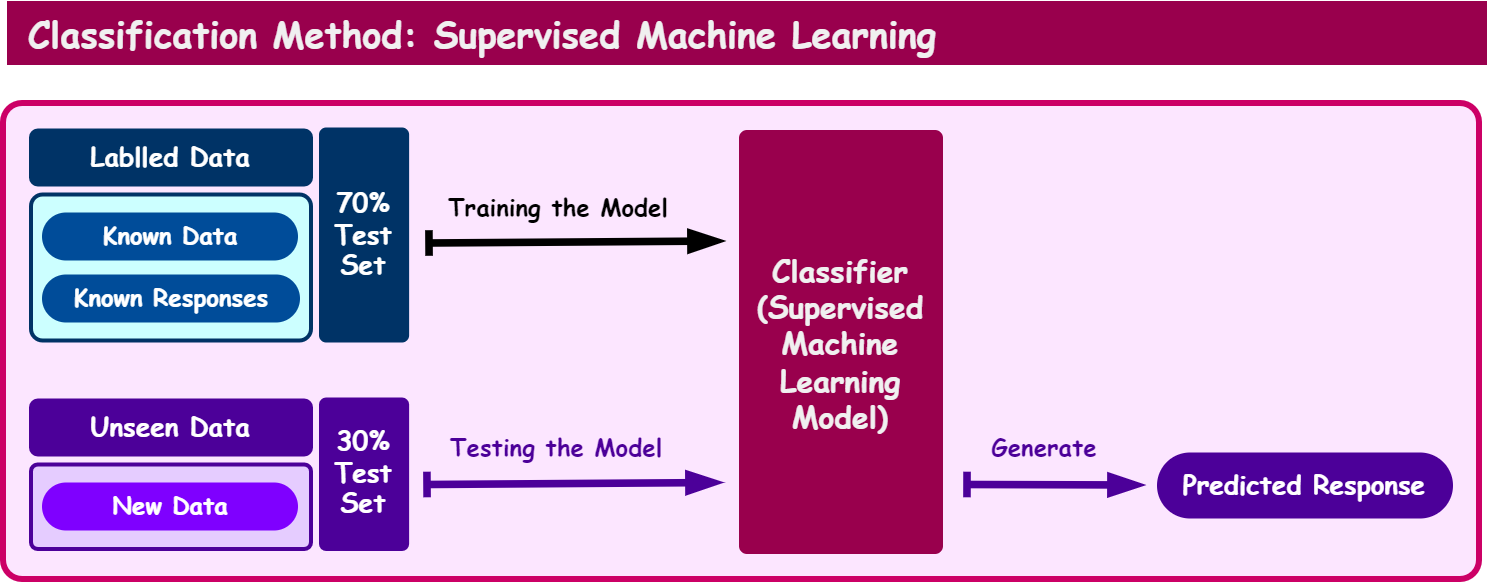

| Stage    | Input                              | Output              |
|----------|------------------------------------|---------------------|
| Training | Labelled documents + known classes | Trained classifier  |
| Testing  | Unseen document + trained classifier | Predicted class   |

Common supervised learning algorithms used in text classification include **Naïve Bayes**, 
**logistic regression**, **maximum entropy**, **decision trees**, and 
**support vector machines**. The following section covers Naïve Bayes in detail.

---


### **Linear Classifier: Naïve Bayes Assumption and Naïve Bayes Model**

####  **Bag of Words**

The **bag of words** model represents text as an unordered collection of words, disregarding  grammar and word order but retaining word frequency. Each word's occurrence count is used as a feature for training a classifier (Jurafsky & Martin, 2021).

**Example — Movie Review:**
> *"I love this movie! It's sweet, but with satirical humor. The dialogue is great and the adventure scenes are fun... It manages to be whimsical and romantic while laughing at the conventions of the fairy tale genre. I would recommend it to just about anyone. I've seen it several times, and I'm always happy to see it again whenever I have a friend who hasn't seen it yet!"*

As illustrated in **Figure** below, the review is broken down into individual words and their frequencies, ignoring the original order:

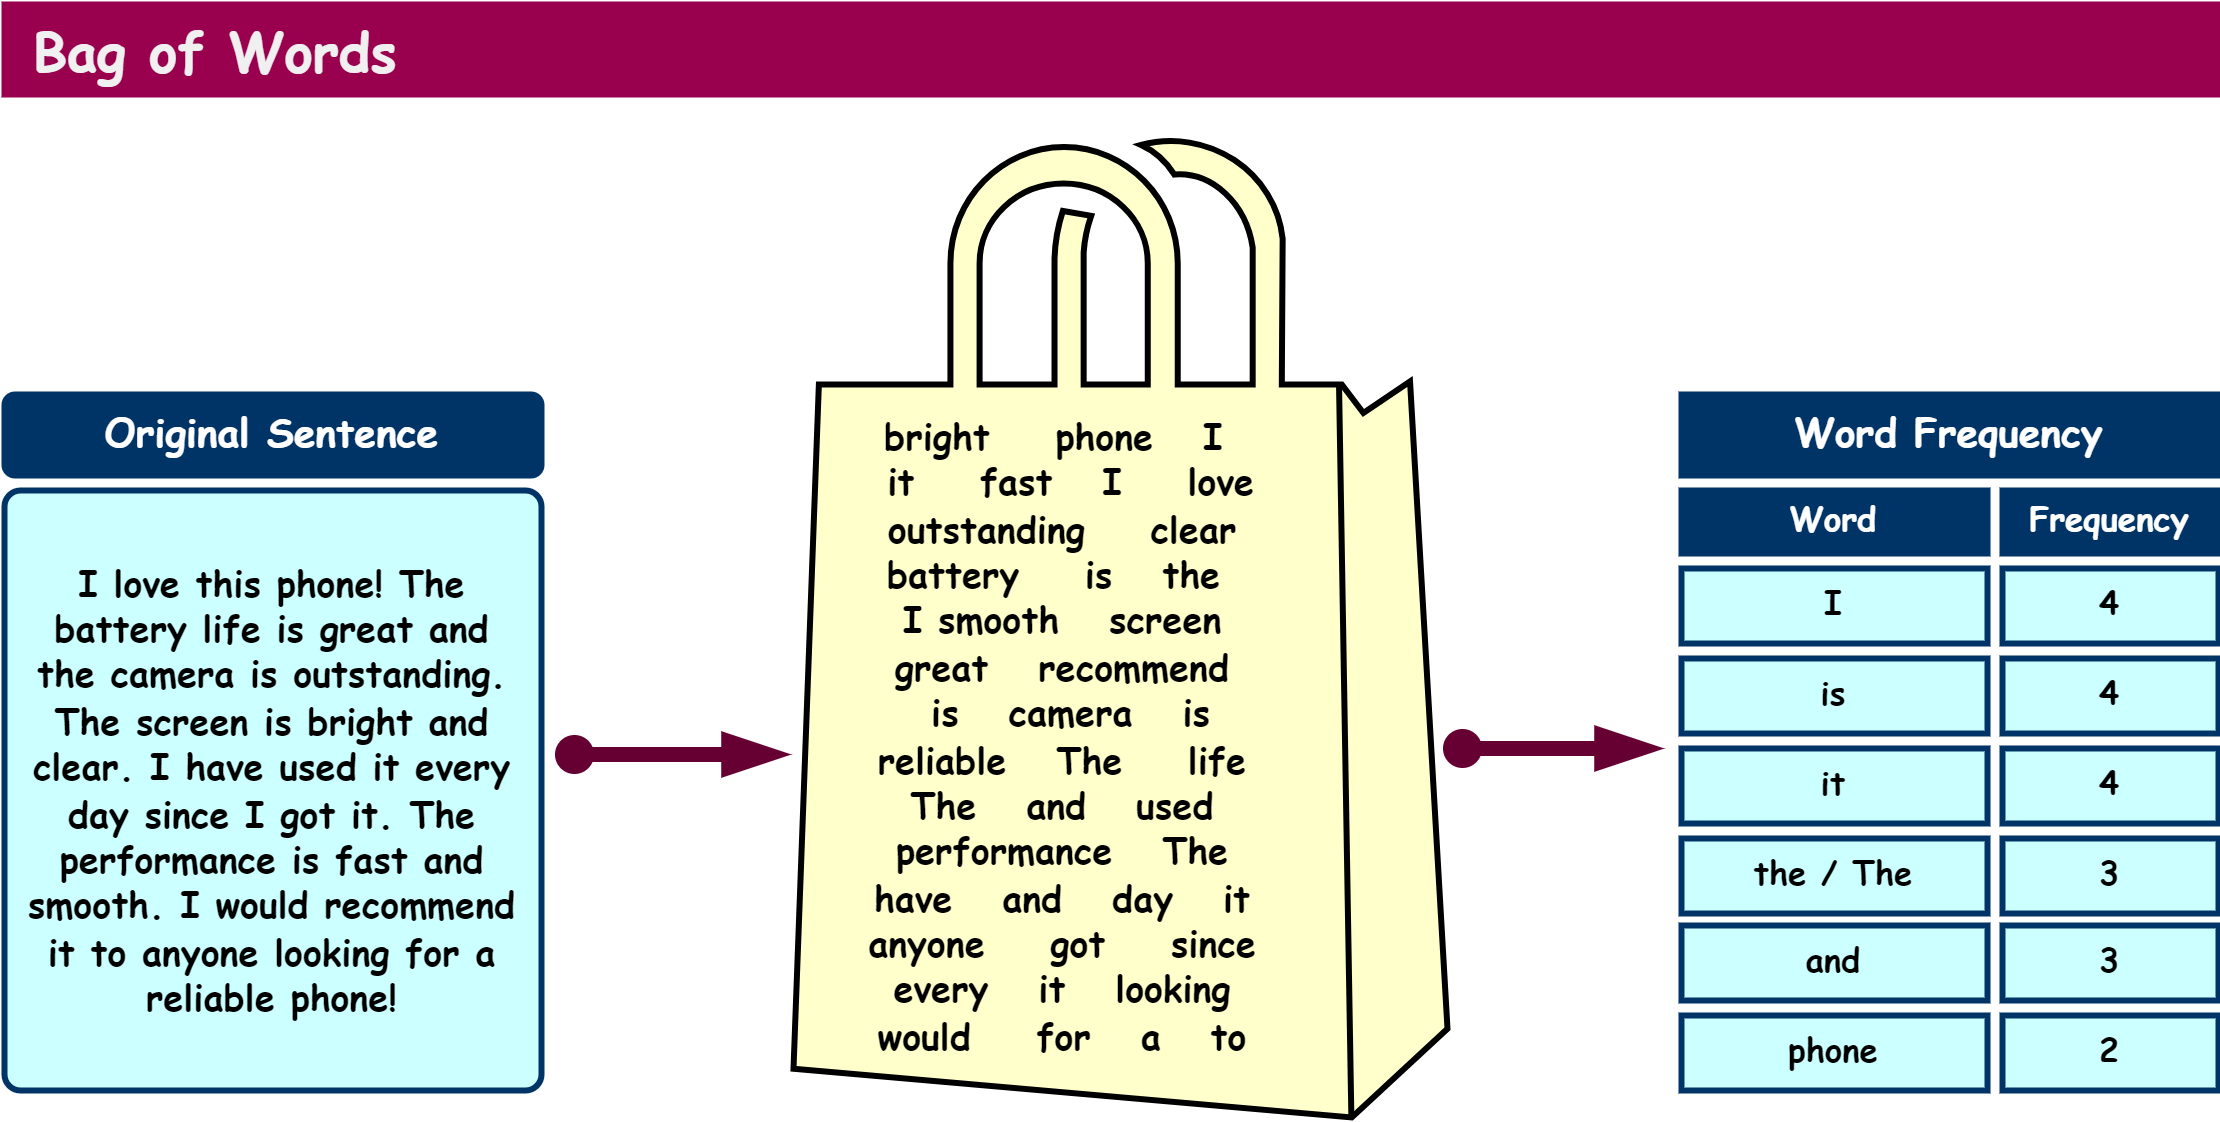

*Figure: Intuition of the multinomial Naïve Bayes classifier applied to a movie review. Word position is ignored (the bag of words assumption) and word frequency is used instead.*

<br>

#### **Conditional Independence**

**Conditional independence** means that the presence of one feature does not influence the presence of another when predicting an outcome. A simple analogy: rolling two dice independently, the result of one die tells you nothing about the other.

In the **Naïve Bayes classifier**, it is assumed that the effect of each predictor (x) on a given class (c) is independent of all other predictors. This is known as **class conditional independence**, and it is the core assumption that makes Naïve Bayes computationally simple and efficient.

<br>

#### **Naïve Bayes Model**

To classify a document, we want to find the most probable class $\hat{c}$ given document $d$:

$$\hat{c} = \arg\max_{c \in C} P(c \mid d) \tag{1}$$

Applying **Bayes' rule** to equation [1]:

$$= \arg\max_{c \in C} \frac{P(d \mid c) P(c)}{P(d)} \tag{2}$$

Since $P(d)$ is constant across all classes, we can omit the denominator:

$$= \arg\max_{c \in C} P(d \mid c) P(c) \tag{3}$$

This allows us to approximate what we don't know using values we can calculate from the corpus.

<br>

#### **Representing Documents as Features**

A document is represented as a set of features $f_1, f_2, \ldots, f_n$ (e.g. words like *'werewolf'* or *'humanity'*):

$$\hat{c} = \arg\max_{c \in C} P(f_1, f_2, \ldots, f_n \mid c) \cdot P(c)$$

Where:
- $P(f_1, f_2, \ldots, f_n \mid c)$ — the **likelihood** of the features given class $c$
- $P(c)$ — the **prior** probability of class $c$

<br>

#### **Estimating Prior Probability from Corpus Data**

$P(c)$ is estimated from the relative frequency of each class in the training data.

**Example — Toy Sentiment Corpus:**

| Doc | Class | Words                              |
|-----|-------|------------------------------------|
| 1   | −     | predictable film predictable       |
| 2   | −     | predictable predictable dull       |
| 3   | −     | predictable spoof                  |
| 4   | +     | fun powerful predictable           |
| ?   | 5     | predictable predictable predictable fun powerful |

From this corpus: $P(+) = \frac{1}{4}$, $P(-) = \frac{3}{4}$

<br>

#### **Addressing Data Sparsity with Naïve Bayes Assumptions**

Computing $P(f_1, f_2, \ldots, f_n \mid c)$ directly causes **data sparsity** — it is unlikely to find enough training examples with the exact same sequence of features. Naïve Bayes resolves this using two key assumptions:

- **Bag of words assumption:** feature position does not matter
- **Conditional independence assumption:** each feature probability depends only on class $c$

This simplifies the likelihood calculation to:

$$P(f_1, f_2, \ldots, f_n \mid c) \approx P(f_1 \mid c) \times P(f_2 \mid c) \times \ldots \times P(f_n \mid c)$$

This significantly reduces the data sparsity problem (Monash Online, 2022).

<br>

#### **Applying Naïve Bayes to Text Classification**

Substituting the conditional independence assumption into the classification equation gives us the **Naïve Bayes classifier**:

$$C_{NB} = \arg\max_{c \in C} P(c) \prod_{f \in F} P(f \mid c)$$

At test time, we walk through each word position in the document:

$$C_{NB} = \arg\max_{c \in C} P(c) \prod_{i \in \text{positions}} P(w_i \mid c)$$

We estimate word probabilities using maximum likelihood from the training corpus:

$$\hat{P}(w_i \mid c) = \frac{\text{count}(w_i, c)}{\sum_{w \in V} \text{count}(w, c)}$$

<br>

### **Worked Example**

Using the toy sentiment corpus from section 4.3, we calculate the word probabilities for each class:

| Word        | $P(w \mid c = +)$ | $P(w \mid c = -)$ |
|-------------|:-----------------:|:-----------------:|
| dull        | $0$               | $\frac{1}{7}$     |
| film        | $\frac{1}{3}$     | $\frac{1}{7}$     |
| fun         | $\frac{1}{3}$     | $\frac{1}{7}$     |
| powerful    | $\frac{1}{3}$     | $\frac{1}{7}$     |
| predictable | $\frac{1}{3}$     | $\frac{5}{7}$     |
| spoof       | $\frac{1}{3}$     | $\frac{1}{7}$     |

Zero values of *fun* and *powerful* will cause the probability of the test sentence to be zero — despite any other evidence!

<br>

#### **Add-1 (Laplace) Smoothing**

To handle zero probabilities, we apply **Add-1 smoothing**, where $|V|$ is the number of unique words in the vocabulary:

$$\hat{P}(w_i \mid c) = \frac{\text{count}(w_i, c) + 1}{\sum_{w \in V} \text{count}(w, c) + |V|}$$

Applying this to our data:

| Word        | $P(w \mid c = +)$                          | $P(w \mid c = -)$                           |
|-------------|:------------------------------------------:|:-------------------------------------------:|
| dull        | $\frac{0+1}{3+6} = \frac{1}{9}$            | $\frac{1+1}{8+6} = \frac{2}{14}$            |
| film        | $\frac{1+1}{3+6} = \frac{2}{9}$            | $\frac{1+1}{8+6} = \frac{2}{14}$            |
| fun         | $\frac{1+1}{3+6} = \frac{2}{9}$            | $\frac{0+1}{8+6} = \frac{1}{14}$            |
| powerful    | $\frac{0+1}{3+6} = \frac{1}{9}$            | $\frac{0+1}{8+6} = \frac{1}{14}$            |
| predictable | $\frac{1+1}{3+6} = \frac{2}{9}$            | $\frac{5+1}{8+6} = \frac{6}{14}$            |
| spoof       | $\frac{0+1}{3+6} = \frac{1}{9}$            | $\frac{0+1}{8+6} = \frac{1}{14}$            |

<br>

#### **Final Prediction for Test Document $d_5$**

Using the full formula to classify $d_5$ = *"predictable predictable predictable fun powerful"*:

$$\hat{P}(+ \mid d_5) = \frac{1}{4} \times \left(\frac{2}{9}\right)^3 \times \frac{2}{9} \times \frac{2}{9} = 0.000135$$

$$\hat{P}(- \mid d_5) = \frac{3}{4} \times \left(\frac{6}{14}\right)^3 \times \frac{1}{14} \times \frac{1}{14} = 0.000301$$

Since $\hat{P}(- \mid d_5) > \hat{P}(+ \mid d_5)$, the classifier predicts $d_5$ as **negative**.

---

### **Optimising for Sentiment Analysis**

Optimisation techniques for sentiment analysis are essentially ways to make the Naïve Bayes classifier more accurate when analysing opinions or emotions in text. Several techniques can improve Naïve Bayes performance for sentiment analysis:

- **Clipped word counts:** Use the presence or absence of a word rather than its frequency. 
  Remove duplicate words during pre-processing.
- **Handling negation:** Words like *'didn't like'* shift inference — *'NOT like'* appears 
  more often in negative documents.
- **Handling intensifiers:** Adjust weights based on intensity, e.g. *'slightly entertaining'* 
  (×0.5) versus *'extraordinarily entertaining'* (×1.5).
- **Detecting irrealis markers:** Indicators of non-factual statements, e.g. *'I thought this 
  movie would be as good as the Grinch, but unfortunately…'* versus *'this could be one of the 
  best of the holiday season.'*
- **Sentiment lexicons:** Examples include General Inquirer, the Maryland dictionary, and the 
  MPQA Subjectivity dictionary.

Taboada et al. (2011) argue that weighted unigrams from supervised methods can sometimes be too domain-specific — for example, actor names or words like *'series'* or *'video'* in movie reviews may skew results.

The table below compares classification performance (% correct) across different dictionaries using SO-CAL:

| Dictionary            | Epinions 1 | Epinions 2 | Movie | Camera | Overall |
|-----------------------|:----------:|:----------:|:-----:|:------:|:-------:|
| Google-Full           | 62.00      | 58.50      | 66.31 | 61.25  | 62.98   |
| Google-Basic          | 53.25      | 53.50      | 67.42 | 51.40  | 59.25   |
| Maryland-Full-NoW     | 58.00      | 63.75      | 67.42 | 59.46  | 62.65   |
| Maryland-Basic        | 56.50      | 56.00      | 62.26 | 53.79  | 58.16   |
| GI-Full               | 68.00      | 70.50      | 64.21 | 72.33  | 68.02   |
| GI-Basic              | 62.50      | 59.00      | 65.68 | 63.87  | 64.23   |
| SentiWordNet-Full     | 66.50      | 66.50      | 61.89 | 67.00  | 65.02   |
| SentiWordNet-Basic    | 59.25      | 62.50      | 62.89 | 59.92  | 61.47   |
| Subjectivity-Full     | 72.75      | 71.75      | 65.42 | 77.21  | 72.04   |
| Subjectivity-Basic    | 64.75      | 63.50      | 68.63 | 64.83  | 66.51   |
| **SO-CAL-Full**       | **80.25**  | **80.00**  | **76.37** | **80.16** | **78.74** |
| SO-CAL-Basic          | 65.50      | 65.25      | 68.05 | 64.70  | 66.04   |